In [1]:
import os
os.chdir("../../../../..")

In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dscribe.kernels import REMatchKernel
from loguru import logger
from umap import UMAP
from rdkit import Chem
from scipy.spatial.distance import cdist
import logging
from typing import Any, List, Dict, Sequence
import numpy as np
import polars as pl
from ase import Atoms
from scipy.spatial.distance import cdist
from ripser import ripser
import persim
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.metrics import silhouette_score

from src.non_euclidean import Wasserstein, PersistentHomology, REMatch
from src.datasets import QM9Dataset

In [ ]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-06-01 10:43:38.772 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-06-01 10:43:39.287 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-06-01 10:43:39.291 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-06-01 10:43:39.376 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-06-01 10:46:37.863 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-06-01 10:46:37.948 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-06-01 10:46:38.052 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering 

# Hypothesis 1

In [3]:
def generate_3d_molecule(smiles: str) -> Dict[str, Any]:
    """Generates explicit 3D conformations and extracts positions/atomic numbers."""
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)  # Retain hydrogens for explicit physical filtration
    AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
    AllChem.MMFFOptimizeMolecule(mol)  # Energy minimize to enforce realistic bond lengths
    
    conformer = mol.GetConformer()
    coordinates = conformer.GetPositions().tolist()
    atomic_numbers = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    
    return {
        "atomic_numbers": atomic_numbers,
        "coordinates": coordinates,
        "pbc": [False, False, False] # Explicit open boundaries for QM9-like finite structures
    }

In [11]:
def plot_molecular_persistence(
    formatted_dgm: Dict[int, np.ndarray], 
    molecule_name: str,
    ax: plt.Axes = None,
    lifespan_threshold: float = 0.70
) -> plt.Axes:
    """
    Plots a professional 2D birth-death persistence diagram for a single molecule.
    Accepts an external matplotlib axis object for subplot integration.
    """
    # Fallback to standalone figure if no axis is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    
    styles = {
        0: {"color": "#1f77b4", "marker": "o", "label": "$H_0$ (Components)"},
        1: {"color": "#ff7f0e", "marker": "s", "label": "$H_1$ (Rings/Cycles)"}
    }
    
    max_val = 0.0
    for dim in sorted(formatted_dgm.keys()):
        if dim not in styles:
            continue
        dgm_layer = formatted_dgm[dim]
        if len(dgm_layer) == 0:
            continue
            
        max_val = max(max_val, np.max(dgm_layer))
        
        ax.scatter(
            dgm_layer[:, 0], 
            dgm_layer[:, 1], 
            color=styles[dim]["color"],
            marker=styles[dim]["marker"],
            label=styles[dim]["label"],
            alpha=0.7,
            s=40,
            edgecolors='k',
            linewidths=0.5
        )
        
        # Annotate features that overcome local structural/branching noise
        if dim == 1:
            lifespans = dgm_layer[:, 1] - dgm_layer[:, 0]
            for idx, lifespan in enumerate(lifespans):
                if lifespan >= lifespan_threshold:
                    ax.annotate(
                        f"Ring ({lifespan:.2f}Å)",
                        (dgm_layer[idx, 0], dgm_layer[idx, 1]),
                        textcoords="offset points",
                        xytext=(8, -4),
                        ha='left',
                        fontsize=8,
                        fontweight='bold',
                        color='#d62728'
                    )

    axis_limit = max_val * 1.15 if max_val > 0 else 4.0
    ax.plot([0, axis_limit], [0, axis_limit], color="grey", linestyle="--", alpha=0.5, label="B = D")
    
    ax.set_xlim(-0.05, axis_limit)
    ax.set_ylim(-0.05, axis_limit)
    ax.set_xlabel("Birth ($\epsilon$ / Å)", fontsize=10)
    ax.set_ylabel("Death ($\epsilon$ / Å)", fontsize=10)
    ax.set_title(molecule_name, fontsize=11, fontweight='bold')
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none", fontsize=8)
    
    return ax

<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:63: SyntaxWarning: invalid escape sequence '\e'
<>:64: SyntaxWarning: invalid escape sequence '\e'
/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_6841/4033709351.py:63: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("Birth ($\epsilon$ / Å)", fontsize=10)
/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_6841/4033709351.py:64: SyntaxWarning: invalid escape sequence '\e'
  ax.set_ylabel("Death ($\epsilon$ / Å)", fontsize=10)



EXPERIMENTAL RESULTS: H1 TOPOLOGICAL LIFESPANS

Molecule: 2,2,4-Trimethylpentane
 -> H1 Features Detected: 2
 -> Max Lifespan Feature: Birth = 2.1177 Å | Death = 2.7277 Å
 -> Max H1 Lifespan (Δϵ): 0.6100 Å

Molecule: Benzene
 -> H1 Features Detected: 1
 -> Max Lifespan Feature: Birth = 1.3948 Å | Death = 2.4159 Å
 -> Max H1 Lifespan (Δϵ): 1.0211 Å

Molecule: Cyclooctane
 -> H1 Features Detected: 3
 -> Max Lifespan Feature: Birth = 1.5341 Å | Death = 2.7049 Å
 -> Max H1 Lifespan (Δϵ): 1.1709 Å

Molecule: Norbornane
 -> H1 Features Detected: 2
 -> Max Lifespan Feature: Birth = 1.5381 Å | Death = 2.3801 Å
 -> Max H1 Lifespan (Δϵ): 0.8420 Å


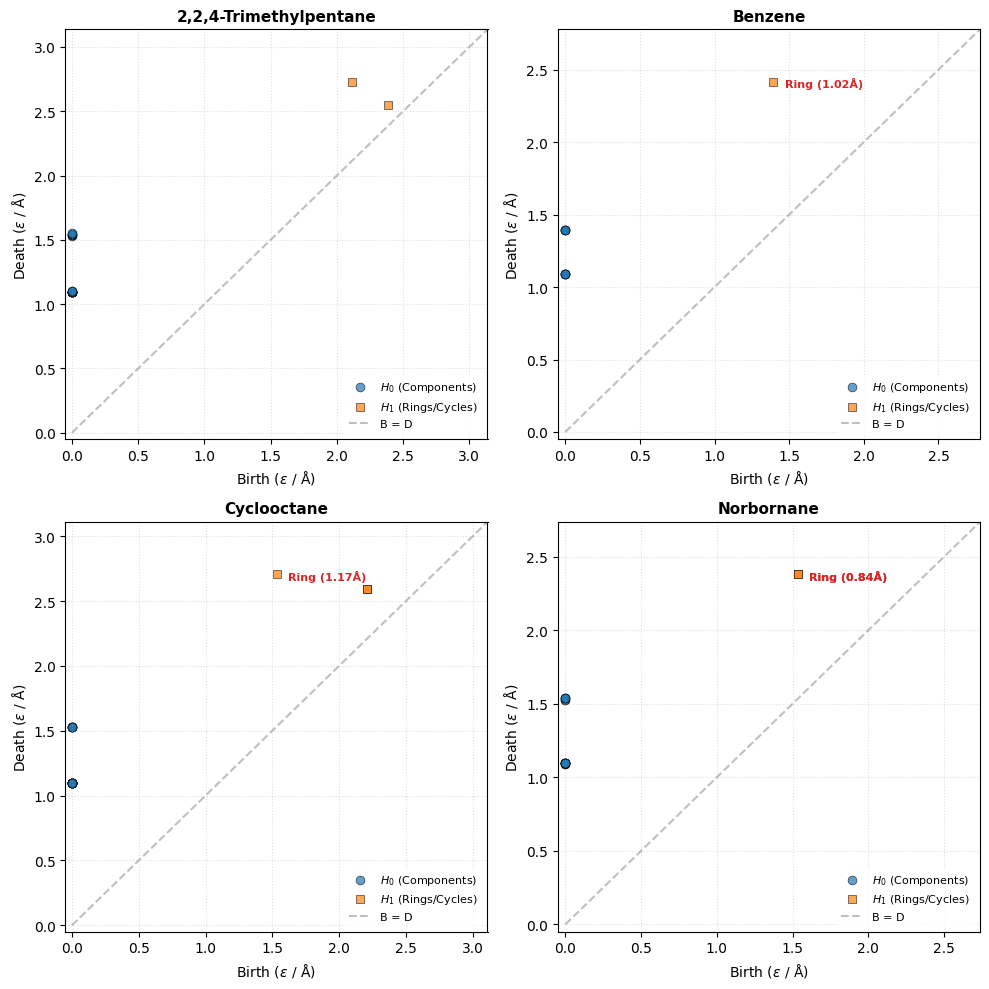

In [ ]:
molecules_data = [
    {"name": "2,2,4-Trimethylpentane", "smiles": "CC(C)CC(C)(C)C"}, 
    {"name": "Benzene", "smiles": "c1ccccc1"},                
    {"name": "Cyclooctane", "smiles": "C1CCCCCCC1"},            
    {"name": "Norbornane", "smiles": "C1CC2CCC1C2"}         
]

# Step 1: Batch process all geometries cleanly up-front
processed_rows = []
for mol in molecules_data:
    geom = generate_3d_molecule(mol["smiles"])
    processed_rows.append({
        "name": mol["name"],
        "atomic_numbers": geom["atomic_numbers"],
        "coordinates": geom["coordinates"],
        "pbc": geom["pbc"]
    })
df_experiment = pl.DataFrame(processed_rows)

# Step 2: Compute diagrams for the whole dataset in a single matrix pass
diagrams = PersistentHomology._get_persistence_diagrams(
    df=df_experiment, 
    descriptor='coordinates', 
    max_homology_dim=1
)

# Step 3: Setup a clean 2x2 grid tailored for publication layout
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes_flat = axes.flatten()

print("\n" + "="*50)
print("EXPERIMENTAL RESULTS: H1 TOPOLOGICAL LIFESPANS")
print("="*50)

# Step 4: Map diagrams to subplots and output analytics
for idx, (row, dgm) in enumerate(zip(df_experiment.iter_rows(named=True), diagrams)):
    name = row["name"]
    h1_features = dgm[1]
    
    # Route the diagram directly to its designated panel in the grid
    plot_molecular_persistence(dgm, name, ax=axes_flat[idx])
    
    print(f"\nMolecule: {name}")
    if len(h1_features) == 0:
        print(" -> H1 Features Detected: 0")
        print(" -> Max H1 Lifespan: 0.0000 Å")
    else:
        lifespans = h1_features[:, 1] - h1_features[:, 0]
        max_idx = np.argmax(lifespans)
        birth, death = h1_features[max_idx]
        print(f" -> H1 Features Detected: {len(h1_features)}")
        print(f" -> Max Lifespan Feature: Birth = {birth:.4f} Å | Death = {death:.4f} Å")
        print(f" -> Max H1 Lifespan (Δϵ): {lifespans[max_idx]:.4f} Å")

plt.sidebar = None
plt.tight_layout()
plt.show()